<a href="https://colab.research.google.com/github/alimohmedelsaid26-cell/1000MLEngineer/blob/main/Text_classification_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Import required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

In [ ]:
#Load & Pre-process data
!wget --no-check-certificate \
    https://storage.googleapis.com/laurenceanthony-grego-prd.appspot.com/bbc-text.csv \
    -O /tmp/bbc-text.csv

--2026-03-24 12:09:36--  https://storage.googleapis.com/laurenceanthony-grego-prd.appspot.com/bbc-text.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.181.207, 173.194.64.207, 173.194.193.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.181.207|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-24 12:09:36 ERROR 404: Not Found.



In [ ]:
#Initializing Parameters
vocab_size = 1000
embedding_dim = 16
max_length = 120
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"
training_portion = .8
sentences=[]
labels=[]
stopwords = [ "a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "he'd", "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "it", "it's", "its", "itself", "let's", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "she'd", "she'll", "she's", "should", "so", "some", "such", "t", "than", "that", "that's", "the", "their", "theirs", "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "we'd", "we'll", "we're", "we've", "were", "what", "what's", "when", "when's", "where", "where's", "which", "while", "who", "who's", "whom", "why", "why's", "with", "would", "you", "you'd", "you'll", "you're", "you've", "your", "yours", "yourself", "yourselves" ]

In [ ]:
# Splitting Data
train_size = int(len(sentences) * training_portion)

train_sentences = sentences[:train_size]
train_labels = labels[:train_size]

validation_sentences = sentences[train_size:]
validation_labels = labels[train_size:]

print(train_size)
print(len(train_sentences))
print(len(train_labels))
print(len(validation_sentences))
print(len(validation_labels))

1780
1780
1780
445
445


In [31]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# The training process starts here
history = model.fit(
    train_padded,
    training_label_seq, # Changed from train_labels to training_label_seq
    epochs=30,
    validation_data=(validation_padded, validation_label_seq), # Changed from validation_labels to validation_label_seq
    verbose=2
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


56/56 - 2s - 35ms/step - accuracy: 0.2360 - loss: 1.7186 - val_accuracy: 0.1910 - val_loss: 1.6507
Epoch 2/30
56/56 - 0s - 7ms/step - accuracy: 0.3669 - loss: 1.5936 - val_accuracy: 0.3393 - val_loss: 1.5511
Epoch 3/30
56/56 - 1s - 11ms/step - accuracy: 0.4624 - loss: 1.4966 - val_accuracy: 0.5483 - val_loss: 1.4564
Epoch 4/30
56/56 - 0s - 8ms/step - accuracy: 0.5713 - loss: 1.3906 - val_accuracy: 0.5798 - val_loss: 1.3460
Epoch 5/30
56/56 - 0s - 6ms/step - accuracy: 0.7090 - loss: 1.2462 - val_accuracy: 0.6854 - val_loss: 1.1828
Epoch 6/30
56/56 - 0s - 5ms/step - accuracy: 0.8062 - loss: 1.0700 - val_accuracy: 0.8270 - val_loss: 1.0238
Epoch 7/30
56/56 - 0s - 5ms/step - accuracy: 0.8438 - loss: 0.8936 - val_accuracy: 0.8787 - val_loss: 0.8588
Epoch 8/30
56/56 - 0s - 5ms/step - accuracy: 0.8860 - loss: 0.7353 - val_accuracy: 0.8989 - val_loss: 0.7127
Epoch 9/30
56/56 - 0s - 5ms/step - accuracy: 0.9112 - loss: 0.6028 - val_accuracy: 0.8831 - val_loss: 0.6098
Epoch 10/30
56/56 - 0s - 5ms

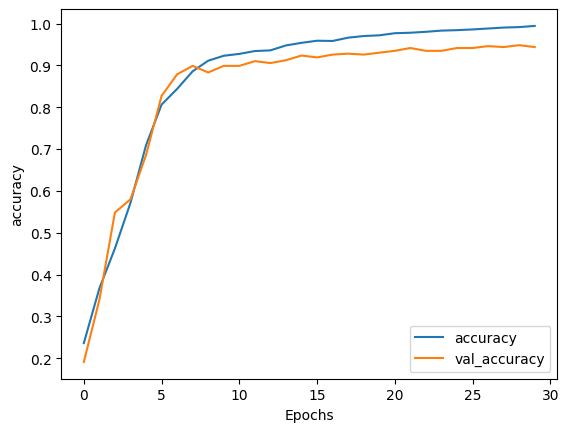

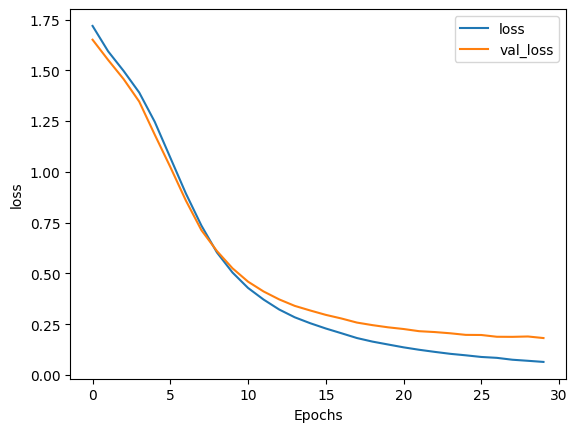

In [33]:
# Plotting training history
import matplotlib.pyplot as plt

def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")